In [21]:
import pandas as pd
import os
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import json
import ast
from scipy.signal import savgol_filter
mpl.rcParams.update({
    "text.usetex": True,              # Enable LaTeX
    # "font.family": "serif",
    # "font.serif": ["Times New Roman"], # Use Times New Roman
    "text.latex.preamble": r"\usepackage{amsmath}"
})

plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"

In [22]:
# Define a function to convert the string representation of an array/list
def string_to_array(array_string):
    try:
        # Use ast.literal_eval to safely evaluate the string as a Python literal
        return ast.literal_eval(array_string)
    except (ValueError, SyntaxError):
        # Handle cases where the string might not be a valid list/array string
        return array_string # Or some default/error value

In [23]:
exp_filepath = "exp_data/full_trained_model_03/forward_stop/full_12Lwater_push.csv"

payload_df = pd.read_csv(exp_filepath, converters={'base_cmd': string_to_array,
                                           'base_pose': string_to_array,
                                           'base_rpy': string_to_array,
                                           'dof_pose': string_to_array,
                                           'base_lin_vel': string_to_array,
                                           'base_ang_vel': string_to_array,
                                           'dof_vel': string_to_array,
                                           'proj_grav': string_to_array,
                                           'feet_pos': string_to_array,
                                           'tau_act': string_to_array,
                                           'grf': string_to_array,
                                           'q_des': string_to_array,
                                           'tau_ff': string_to_array,
                                           'tau_pd': string_to_array,
                                           'failure': string_to_array,
                                           'pred_grf': string_to_array})

print(len(payload_df))

800


In [24]:
# Joint tracking / violation metrics
q_actions      = np.array(payload_df["q_des"].to_list())
q_observations = np.array(payload_df["dof_pose"].to_list())

# cmd tracking metrics
vel_cmds = np.array(payload_df["base_cmd"].to_list())  # v_x, v_y, w_yaw
lin_vel  = np.array(payload_df["base_lin_vel"].to_list())
ang_vel  = np.array(payload_df["base_ang_vel"].to_list())   # stability via roll/pitch angular velo.

# Height tracking metric
base_pose = np.array(payload_df["base_pose"].to_list())

# Oreintation
proj_grav = np.array(payload_df["proj_grav"].to_list())

# joint power metric
q_vel = np.array(payload_df["dof_vel"].to_list())
q_tau = np.array(payload_df["tau_act"].to_list())
# alignment metric, ratio metric
ff_tau = np.array(payload_df["tau_ff"].to_list())
pd_tau = np.array(payload_df["tau_pd"].to_list())

grfs = np.array(payload_df["grf"].to_list())
grf_pred = np.array(payload_df["pred_grf"].to_list())

joint_limits = np.array([[-1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721, -1.047, -0.633, -2.721],
                         [1.047, 2.966, -0.837, 1.047, 2.966, -0.837, 1.047, 2.966, -0.837, 1.047, 2.966, -0.837]])

joint_torque_limits = np.array([23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55, 23.7, 23.7, 35.55])

In [25]:
diff = grf_pred*100 - grfs
mse_grf = np.mean(np.square(diff), axis=0)
rmse_grf = np.sqrt(mse_grf)
print("RMSE GRF per leg:", rmse_grf)

RMSE GRF per leg: [  17.60133684   26.0449486  3784.45807599   36.85332907   13.22911116
 3886.72773756   25.07298075   19.915352   3247.6878516    16.14307918
   28.14965899 3251.60848376]


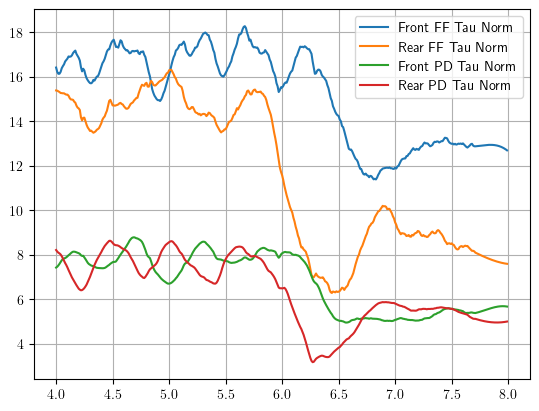

In [26]:
x_ticks = np.arange(len(payload_df)) * 0.01

front_ff_tau_norm = np.linalg.norm(ff_tau[:,0:6], axis=1)
rear_ff_tau_norm  = np.linalg.norm(ff_tau[:,6:12], axis=1)

front_pd_tau_norm = np.linalg.norm(pd_tau[:,0:6], axis=1)
rear_pd_tau_norm  = np.linalg.norm(pd_tau[:,6:12], axis=1)

# Smoothing (window length must be odd)
window = 57      # adjust for smoothness
poly_order = 3


load_front_ff_smooth = savgol_filter(front_ff_tau_norm, window, poly_order)
load_rear_ff_smooth  = savgol_filter(rear_ff_tau_norm,  window, poly_order)

load_front_pd_smooth = savgol_filter(front_pd_tau_norm, window, poly_order)
load_rear_pd_smooth  = savgol_filter(rear_pd_tau_norm,  window, poly_order)
plt.plot(x_ticks[400:], load_front_ff_smooth[400:], label='Front FF Tau Norm')
plt.plot(x_ticks[400:], load_rear_ff_smooth[400:], label='Rear FF Tau Norm')
plt.plot(x_ticks[400:], load_front_pd_smooth[400:], label='Front PD Tau Norm')
plt.plot(x_ticks[400:], load_rear_pd_smooth[400:], label='Rear PD Tau Norm')
plt.grid()
plt.legend()

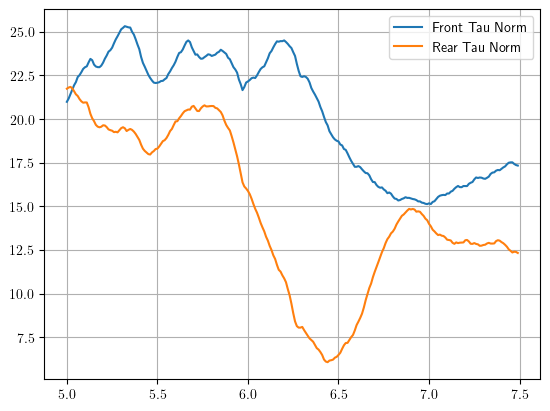

In [27]:
x_ticks = np.arange(len(payload_df)) * 0.01

front_tau_norm = np.linalg.norm(ff_tau[:,0:6] + pd_tau[:,0:6], axis=1)
rear_tau_norm  = np.linalg.norm(ff_tau[:,6:12] + pd_tau[:,6:12], axis=1)

load_total_front_smooth = savgol_filter(front_tau_norm, window, poly_order)
load_total_rear_smooth  = savgol_filter(rear_tau_norm,  window, poly_order)

plt.plot(x_ticks[500:750], load_total_front_smooth[500:750], label='Front Tau Norm')
plt.plot(x_ticks[500:750], load_total_rear_smooth[500:750], label='Rear Tau Norm')
plt.grid()
plt.legend()

In [28]:
exp_filepath = "exp_data/full_trained_model_forward_slosh/full_0Lnone_push.csv"

noload_df = pd.read_csv(exp_filepath, converters={'base_cmd': string_to_array,
                                           'base_pose': string_to_array,
                                           'base_rpy': string_to_array,
                                           'dof_pose': string_to_array,
                                           'base_lin_vel': string_to_array,
                                           'base_ang_vel': string_to_array,
                                           'dof_vel': string_to_array,
                                           'proj_grav': string_to_array,
                                           'feet_pos': string_to_array,
                                           'tau_act': string_to_array,
                                           'grf': string_to_array,
                                           'q_des': string_to_array,
                                           'tau_ff': string_to_array,
                                           'tau_pd': string_to_array,
                                           'failure': string_to_array,
                                           'pred_grf': string_to_array})

print(len(noload_df))

800


In [29]:
# alignment metric, ratio metric
noload_ff_tau = np.array(noload_df["tau_ff"].to_list())
noload_pd_tau = np.array(noload_df["tau_pd"].to_list())

noload_grfs = np.array(noload_df["grf"].to_list())
noload_grf_pred = np.array(noload_df["pred_grf"].to_list())

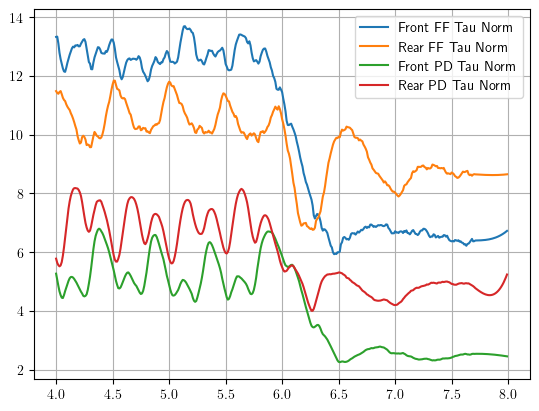

In [30]:
x_ticks = np.arange(len(payload_df)) * 0.01

front_ff_tau_norm = np.linalg.norm(noload_ff_tau[:,0:6], axis=1)
rear_ff_tau_norm  = np.linalg.norm(noload_ff_tau[:,6:12], axis=1)

front_pd_tau_norm = np.linalg.norm(noload_pd_tau[:,0:6], axis=1)
rear_pd_tau_norm  = np.linalg.norm(noload_pd_tau[:,6:12], axis=1)

front_ff_smooth = savgol_filter(front_ff_tau_norm, window, poly_order)
rear_ff_smooth  = savgol_filter(rear_ff_tau_norm,  window, poly_order)

front_pd_smooth = savgol_filter(front_pd_tau_norm, window, poly_order)
rear_pd_smooth  = savgol_filter(rear_pd_tau_norm,  window, poly_order)
plt.plot(x_ticks[400:], front_ff_smooth[400:], label='Front FF Tau Norm')
plt.plot(x_ticks[400:], rear_ff_smooth[400:], label='Rear FF Tau Norm')
plt.plot(x_ticks[400:], front_pd_smooth[400:], label='Front PD Tau Norm')
plt.plot(x_ticks[400:], rear_pd_smooth[400:], label='Rear PD Tau Norm')
plt.grid()
plt.legend()


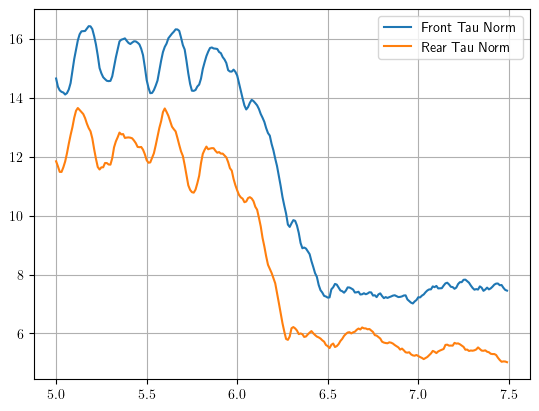

In [31]:
x_ticks = np.arange(len(payload_df)) * 0.01

front_tau_norm = np.linalg.norm(noload_ff_tau[:,0:6] + noload_pd_tau[:,0:6], axis=1)
rear_tau_norm  = np.linalg.norm(noload_ff_tau[:,6:12] + noload_pd_tau[:,6:12], axis=1)
noload_total_front_smooth = savgol_filter(front_tau_norm, window, poly_order)
noload_total_rear_smooth  = savgol_filter(rear_tau_norm,  window, poly_order)

plt.plot(x_ticks[500:750], noload_total_front_smooth[500:750], label='Front Tau Norm')
plt.plot(x_ticks[500:750], noload_total_rear_smooth[500:750], label='Rear Tau Norm')
plt.grid()
plt.legend()

Text(0.5, 1.0, 'Front/Back $\\boldsymbol{\\tau}_{t}^{ex}$ Norm Comparison: 12L Water vs 0L')

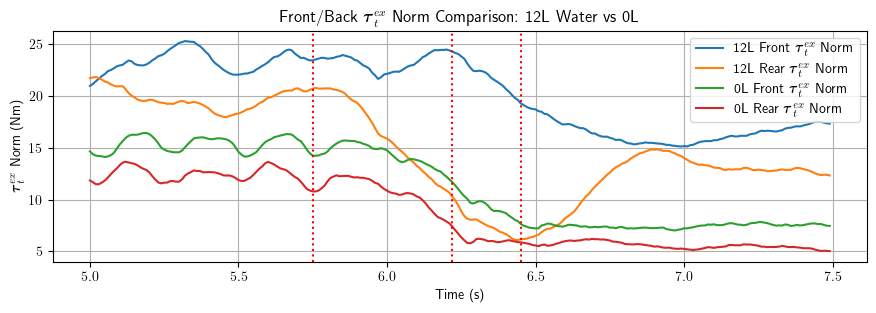

In [32]:
xs = [5.75, 6.22, 6.45]


fig, axs = plt.subplots(1, 1, figsize=(10.5, 3))
axs.plot(x_ticks[500:750], load_total_front_smooth[500:750], label=r"12L Front $\boldsymbol{\tau}_{t}^{ex}$ Norm")
axs.plot(x_ticks[500:750], load_total_rear_smooth[500:750], label=r"12L Rear $\boldsymbol{\tau}_{t}^{ex}$ Norm")
axs.plot(x_ticks[500:750], noload_total_front_smooth[500:750], label=r"0L Front $\boldsymbol{\tau}_{t}^{ex}$ Norm")
axs.plot(x_ticks[500:750], noload_total_rear_smooth[500:750], label=r"0L Rear $\boldsymbol{\tau}_{t}^{ex}$ Norm")

for x in xs:
    plt.axvline(x=x, color="red", linestyle=":", linewidth=1.5)

axs.grid()
axs.legend()
axs.set_xlabel('Time (s)')
axs.set_ylabel(r"$\boldsymbol{\tau}_{t}^{ex}$ Norm (Nm)")
axs.set_title(r"Front/Back $\boldsymbol{\tau}_{t}^{ex}$ Norm Comparison: 12L Water vs 0L")

/tmp/ipykernel_1120143/1727918424.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(np.round(axs[1].get_xticks(),1), fontsize=14)


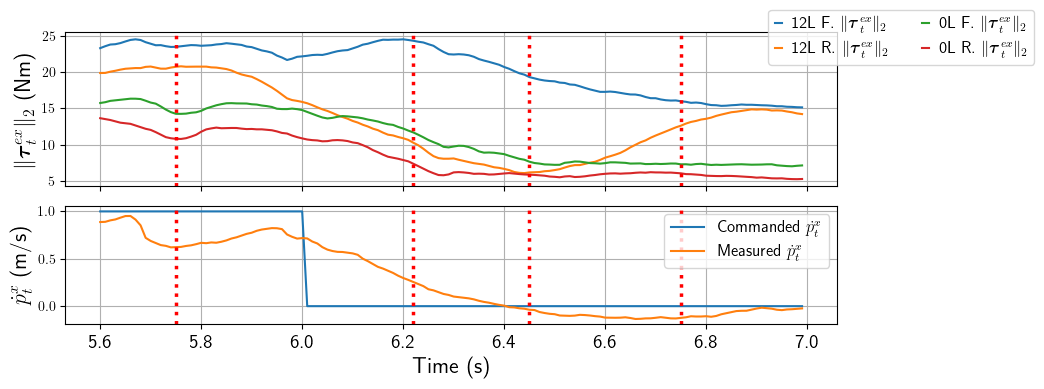

In [33]:
# load_front_ff_smooth = savgol_filter(front_ff_tau_norm, window, poly_order)
# load_rear_ff_smooth  = savgol_filter(rear_ff_tau_norm,  window, poly_order)

# load_front_pd_smooth = savgol_filter(front_pd_tau_norm, window, poly_order)
# load_rear_pd_smooth  = savgol_filter(rear_pd_tau_norm,  window, poly_order)
xs = [5.75, 6.22, 6.45, 6.75]


start_idx = 560
end_idx = 700

fig, axs = plt.subplots(2, 1, figsize=(10.5, 4), sharex=True,  gridspec_kw={"height_ratios": [1.3, 1]})
axs[0].plot(x_ticks[start_idx:end_idx], load_total_front_smooth[start_idx:end_idx], label=r"12L F. $\Vert\boldsymbol{\tau}_{t}^{ex}\Vert_{2}$")
axs[0].plot(x_ticks[start_idx:end_idx], load_total_rear_smooth[start_idx:end_idx], label=r"12L R. $\Vert\boldsymbol{\tau}_{t}^{ex}\Vert_{2}$")
axs[0].plot(x_ticks[start_idx:end_idx], noload_total_front_smooth[start_idx:end_idx], label=r"0L F. $\Vert\boldsymbol{\tau}_{t}^{ex}\Vert_{2}$")
axs[0].plot(x_ticks[start_idx:end_idx], noload_total_rear_smooth[start_idx:end_idx], label=r"0L R. $\Vert\boldsymbol{\tau}_{t}^{ex}\Vert_{2}$")

axs[0].grid()
axs[0].legend(
    loc="upper left",
    bbox_to_anchor=(0.9, 1.2),  # just outside upper-right
    ncol=2,          # or more, depending on entries
    frameon=True,
    fontsize=12,
    handlelength=0.4,    # shorter legend lines
    handletextpad=0.6)    # spacing between line and text)
axs[0].set_ylabel(r"$\Vert\boldsymbol{\tau}_{t}^{ex}\Vert_{2}$ (Nm)", fontsize=16)
# axs[0].set_title(r"Front/Back $\boldsymbol{\tau}_{t}^{ex}$ Norm Comparison: 12L Water vs 0L")


axs[1].plot(x_ticks[start_idx:end_idx], vel_cmds[start_idx:end_idx,0], label=r"Commanded $\dot{p}^{x}_{t}$")
axs[1].plot(x_ticks[start_idx:end_idx], lin_vel[start_idx:end_idx,0], label=r"Measured $\dot{p}^{x}_{t}$")
axs[1].grid()
axs[1].legend(fontsize=12)
axs[1].set_xlabel('Time (s)', fontsize=16)
axs[1].set_xticklabels(np.round(axs[1].get_xticks(),1), fontsize=14)
axs[1].set_ylabel(r"$\dot{p}^{x}_{t}$ (m/s)", fontsize=16)

for x in xs:
    axs[0].axvline(x=x, color="red", linestyle=":", linewidth=2.5)
    axs[1].axvline(x=x, color="red", linestyle=":", linewidth=2.5)

fig.tight_layout()
    
# fig.savefig(
#     "forward_slosh_lineplots.png",
#     dpi=300,
#     bbox_inches="tight",
#     pad_inches=0.02
# )

/tmp/ipykernel_1120143/2577325075.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_yticklabels(np.round(axs.get_yticks(),1), fontsize=14)
/tmp/ipykernel_1120143/2577325075.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs.set_xticklabels(np.round(axs.get_xticks(),1), fontsize=14)


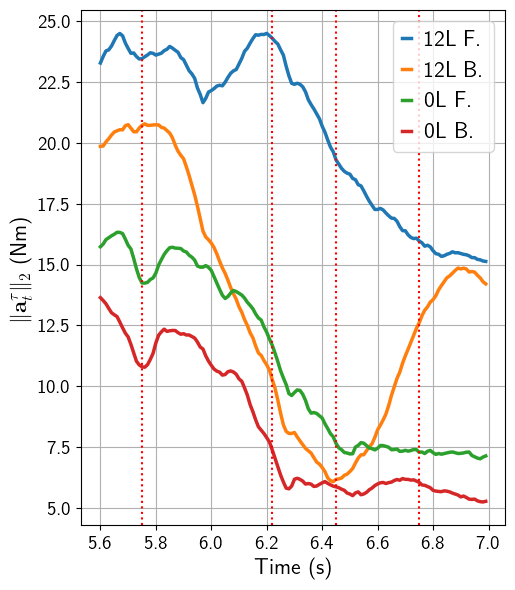

In [37]:
# load_front_ff_smooth = savgol_filter(front_ff_tau_norm, window, poly_order)
# load_rear_ff_smooth  = savgol_filter(rear_ff_tau_norm,  window, poly_order)

# load_front_pd_smooth = savgol_filter(front_pd_tau_norm, window, poly_order)
# load_rear_pd_smooth  = savgol_filter(rear_pd_tau_norm,  window, poly_order)
xs = [5.75, 6.22, 6.45, 6.75]


start_idx = 560
end_idx = 700

fig, axs = plt.subplots(1, 1, figsize=(5.25, 6))
axs.plot(x_ticks[start_idx:end_idx], load_total_front_smooth[start_idx:end_idx], label=r"12L F.", linewidth=2.5)
axs.plot(x_ticks[start_idx:end_idx], load_total_rear_smooth[start_idx:end_idx], label=r"12L B.", linewidth=2.5)
axs.plot(x_ticks[start_idx:end_idx], noload_total_front_smooth[start_idx:end_idx], label=r"0L F.", linewidth=2.5)
axs.plot(x_ticks[start_idx:end_idx], noload_total_rear_smooth[start_idx:end_idx], label=r"0L B.", linewidth=2.5)

axs.grid()
axs.legend(
    # loc="upper left",
    # bbox_to_anchor=(0.9, 1.2),  # just outside upper-right
    ncol=1,          # or more, depending on entries
    frameon=True,
    fontsize=16,
    handlelength=0.4,    # shorter legend lines
    handletextpad=0.6)    # spacing between line and text)
axs.set_ylabel(r"$\Vert\mathbf{a}_{t}^{\tau}\Vert_{2}$ (Nm)", fontsize=16)
axs.set_yticklabels(np.round(axs.get_yticks(),1), fontsize=14)
axs.set_xlabel('Time (s)', fontsize=16)
axs.set_xticklabels(np.round(axs.get_xticks(),1), fontsize=14)

for x in xs:
    axs.axvline(x=x, color="red", linestyle=":", linewidth=1.5)

fig.tight_layout()
    
fig.savefig(
    "forward_slosh_lineplots.png",
    dpi=1000,
    bbox_inches="tight",
    pad_inches=0.02
)